In [3]:
# STEP 1: LOAD THE DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ola_bookings.csv')

print("📊 Original Dataset Shape:", df.shape)
print("\n🔍 Column Names:")
print(df.columns.tolist())
print("\n📋 First 10 Rows:")
print(df.head(10))
print("\n🔢 Data Types:")
print(df.dtypes)
print("\n❓ Missing Values:")
print(df.isnull().sum())
print("\n📈 Booking Status Distribution:")
print(df['Booking Status'].value_counts())


📊 Original Dataset Shape: (49999, 21)

🔍 Column Names:
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled  by Customer', 'Reason for Cancelling by Customer', 'Cancelled Rides by Driver', 'Reason for Cancelling by Driver', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Payment Method', 'Ride Distance', 'Driver Ratings', 'Customer Rating']

📋 First 10 Rows:
         Date      Time  Booking ID       Booking Status  Customer ID  \
0  28/01/2024   6:00:00  CNR1721175              Success       329258   
1  26/01/2024   3:00:00  CNR2871422  Cancelled by Driver       201414   
2  15/01/2024  16:00:00  CNR6875935  Cancelled by Driver       301629   
3  02/01/2024  22:00:00  CNR6798834  Cancelled by Driver       319684   
4  30/01/2024  22:00:00  CNR9661713           Incomplete       330283   
5  14/01/2024  20:00:00  CNR8720322           Incomplete       787277   
6  17/01/2024

In [4]:
# STEP 2: CLEAN DATA AND DROP UNNECESSARY COLUMNS

print("\n🧹 STEP 2: Cleaning Data and Dropping Unnecessary Columns")
print("="*60)

initial_rows = len(df)
initial_cols = len(df.columns)

print(f"Starting with: {initial_rows} rows, {initial_cols} columns")

df = df[df['Booking Status'] == 'Success'].copy()
print(f"✅ Kept only 'Success' bookings: {len(df)} rows ({len(df)/initial_rows*100:.1f}%)")

df = df.dropna(subset=['Pickup Location', 'Date', 'Time'])
print(f"✅ Removed rows with missing location/time data")

df = df.drop_duplicates(subset=['Booking ID'])
print(f"✅ Removed duplicate bookings")

columns_to_keep = [
    'Booking ID',
    'Pickup Location',
    'Drop Location',
    'Date',
    'Time',
    'Vehicle Type',
    'Ride Distance'
]

available_cols = [col for col in columns_to_keep if col in df.columns]
df = df[available_cols].copy()

print(f"\n✅ Column cleanup complete!")
print(f"   Before: {initial_cols} columns")
print(f"   After: {len(df.columns)} columns")
print(f"   Dropped: {initial_cols - len(df.columns)} columns")




🧹 STEP 2: Cleaning Data and Dropping Unnecessary Columns
Starting with: 49999 rows, 21 columns
✅ Kept only 'Success' bookings: 33484 rows (67.0%)
✅ Removed rows with missing location/time data
✅ Removed duplicate bookings

✅ Column cleanup complete!
   Before: 21 columns
   After: 7 columns
   Dropped: 14 columns


In [5]:
# STEP 3: PARSE AREAS AND CREATE TIMESTAMP

print("\n🗺️ STEP 3: Parsing Area Codes and Timestamps")
print("="*60)

def extract_area_id(area_string):
    try:
        return int(area_string.split('-')[1])
    except:
        return None

df['pickup_zone'] = df['Pickup Location'].apply(extract_area_id)
df['dropoff_zone'] = df['Drop Location'].apply(extract_area_id)

df = df.dropna(subset=['pickup_zone'])
df['pickup_zone'] = df['pickup_zone'].astype(int)
df['dropoff_zone'] = df['dropoff_zone'].astype(int)

print(f"✅ Parsed area codes")
print(f"   Unique pickup zones: {df['pickup_zone'].nunique()}")
print(f"   Zone range: {df['pickup_zone'].min()} to {df['pickup_zone'].max()}")

df['booking_timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)

df = df.dropna(subset=['booking_timestamp'])

print(f"✅ Created timestamp")
print(f"   Date range: {df['booking_timestamp'].min()} to {df['booking_timestamp'].max()}")

df = df.drop(columns=['Pickup Location', 'Drop Location', 'Date', 'Time'], errors='ignore')

print(f"\n📋 Current columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

df = df.sort_values('booking_timestamp').reset_index(drop=True)

df.to_csv('rides_parsed.csv', index=False)
print("\n💾 Saved parsed dataset to 'rides_parsed.csv'")



🗺️ STEP 3: Parsing Area Codes and Timestamps
✅ Parsed area codes
   Unique pickup zones: 50
   Zone range: 1 to 50
✅ Created timestamp
   Date range: 2024-01-01 00:00:00 to 2024-01-31 00:00:00

📋 Current columns (6):
   1. Booking ID
   2. Vehicle Type
   3. Ride Distance
   4. pickup_zone
   5. dropoff_zone
   6. booking_timestamp

💾 Saved parsed dataset to 'rides_parsed.csv'



⏰ STEP 4: Extracting Temporal Features
✅ Created temporal features

📋 Current columns (14):
   1. Booking ID
   2. Vehicle Type
   3. Ride Distance
   4. pickup_zone
   5. dropoff_zone
   6. booking_timestamp
   7. hour
   8. day_of_week
   9. is_weekend
   10. time_block
   11. hour_sin
   12. hour_cos
   13. day_sin
   14. day_cos

📋 Sample with temporal features:
   booking_timestamp  pickup_zone  hour  day_of_week  time_block  is_weekend
0         2024-01-01           33     0            0  late_night           0
1         2024-01-01            4     0            0  late_night           0
2         2024-01-01           19     0            0  late_night           0
3         2024-01-01           11     0            0  late_night           0
4         2024-01-01           25     0            0  late_night           0
5         2024-01-01           50     0            0  late_night           0
6         2024-01-01           22     0            0  late_night           0
7         2024

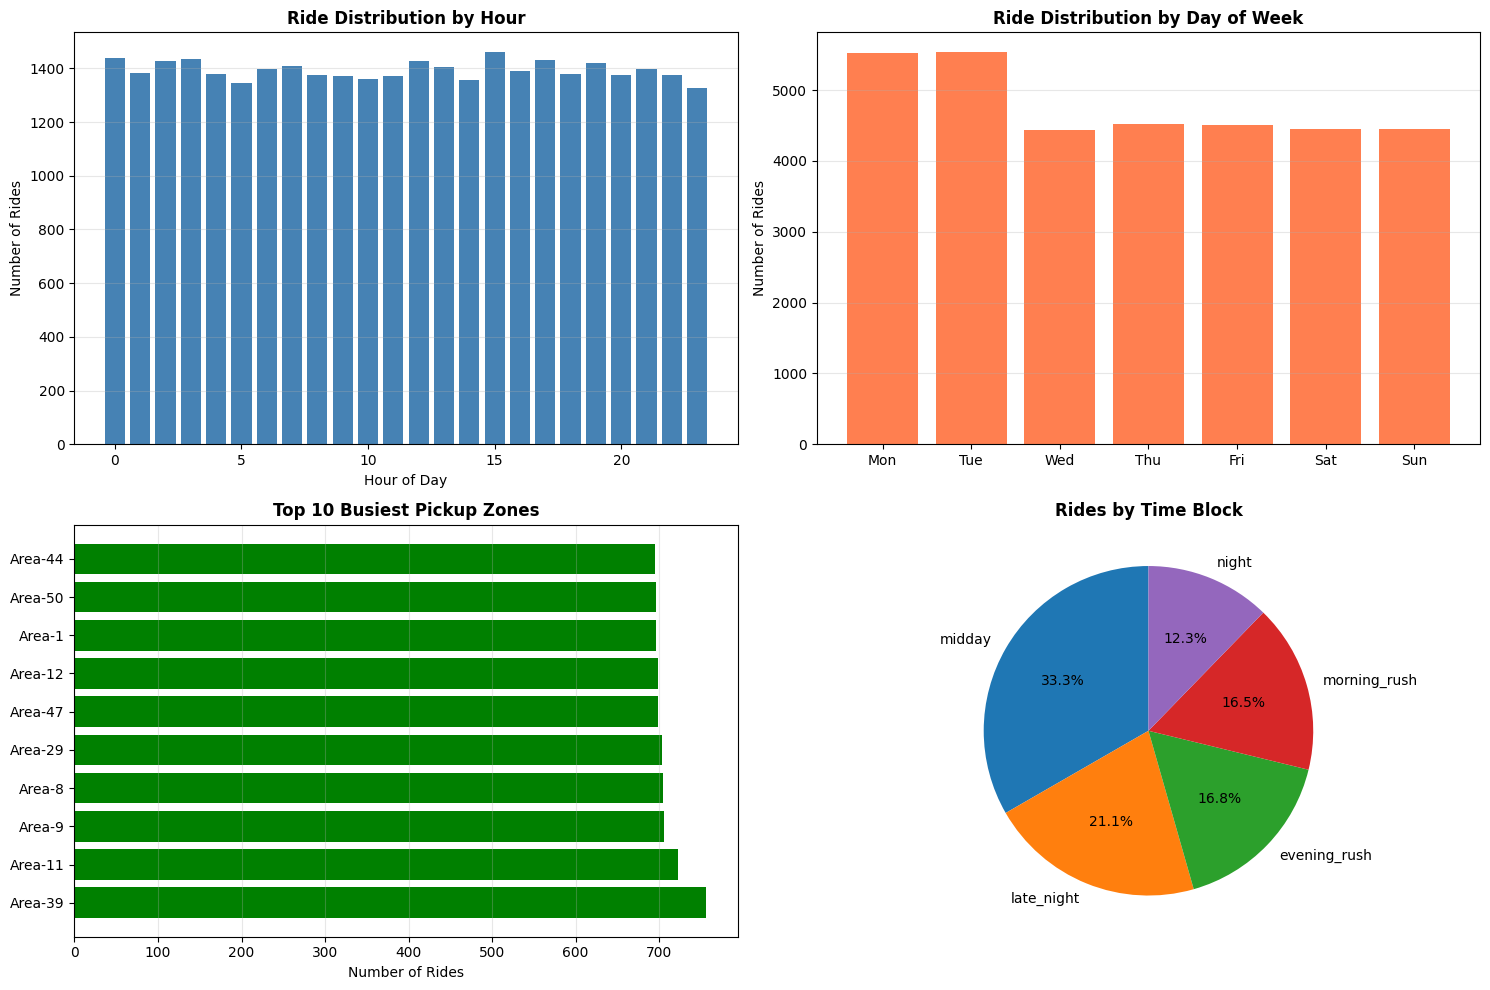


💾 Saved temporal analysis plot to 'temporal_analysis.png'
💾 Saved dataset with features to 'rides_with_features.csv'


In [6]:
# STEP 4: EXTRACT TEMPORAL FEATURES

print("\n⏰ STEP 4: Extracting Temporal Features")
print("="*60)

df['hour'] = df['booking_timestamp'].dt.hour
df['day_of_week'] = df['booking_timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

def categorize_time_block(hour):
    if 5 <= hour < 9:
        return 'morning_rush'
    elif 9 <= hour < 17:
        return 'midday'
    elif 17 <= hour < 21:
        return 'evening_rush'
    elif 21 <= hour < 24:
        return 'night'
    else:
        return 'late_night'

df['time_block'] = df['hour'].apply(categorize_time_block)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print("✅ Created temporal features")

print(f"\n📋 Current columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

print("\n📋 Sample with temporal features:")
sample_cols = ['booking_timestamp', 'pickup_zone', 'hour', 'day_of_week', 'time_block', 'is_weekend']
print(df[sample_cols].head(15))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

hourly_counts = df['hour'].value_counts().sort_index()
axes[0, 0].bar(hourly_counts.index, hourly_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Rides')
axes[0, 0].set_title('Ride Distribution by Hour', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

day_counts = df['day_of_week'].value_counts().sort_index()
axes[0, 1].bar(range(7), day_counts.values, color='coral')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0, 1].set_ylabel('Number of Rides')
axes[0, 1].set_title('Ride Distribution by Day of Week', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

top_zones = df['pickup_zone'].value_counts().head(10)
axes[1, 0].barh(range(10), top_zones.values, color='green')
axes[1, 0].set_yticks(range(10))
axes[1, 0].set_yticklabels([f'Area-{z}' for z in top_zones.index])
axes[1, 0].set_xlabel('Number of Rides')
axes[1, 0].set_title('Top 10 Busiest Pickup Zones', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

block_counts = df['time_block'].value_counts()
axes[1, 1].pie(block_counts.values, labels=block_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Rides by Time Block', fontweight='bold')

plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved temporal analysis plot to 'temporal_analysis.png'")

df.to_csv('rides_with_features.csv', index=False)
print("💾 Saved dataset with features to 'rides_with_features.csv'")


In [7]:
# STEP 5: AGGREGATE TO HOURLY ZONE-LEVEL DATA

print("\n📊 STEP 5: Creating Hourly Zone-Level Aggregations")
print("="*60)

df['hour_timestamp'] = df['booking_timestamp'].dt.floor('H')

print(f"Original dataset: {len(df)} individual rides")

agg_dict = {'Booking ID': 'count'}

if 'Ride Distance' in df.columns:
    agg_dict['Ride Distance'] = 'mean'

if 'Vehicle Type' in df.columns:
    agg_dict['Vehicle Type'] = lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'

hourly_demand = df.groupby(['pickup_zone', 'hour_timestamp']).agg(agg_dict).reset_index()

rename_dict = {'Booking ID': 'ride_count'}
if 'Ride Distance' in df.columns:
    rename_dict['Ride Distance'] = 'avg_distance'
if 'Vehicle Type' in df.columns:
    rename_dict['Vehicle Type'] = 'common_vehicle'

hourly_demand = hourly_demand.rename(columns=rename_dict)

print(f"✅ Aggregated to {len(hourly_demand)} zone-hour combinations")

hourly_demand['hour'] = hourly_demand['hour_timestamp'].dt.hour
hourly_demand['day_of_week'] = hourly_demand['hour_timestamp'].dt.dayofweek
hourly_demand['is_weekend'] = hourly_demand['day_of_week'].isin([5, 6]).astype(int)

hourly_demand['hour_sin'] = np.sin(2 * np.pi * hourly_demand['hour'] / 24)
hourly_demand['hour_cos'] = np.cos(2 * np.pi * hourly_demand['hour'] / 24)
hourly_demand['day_sin'] = np.sin(2 * np.pi * hourly_demand['day_of_week'] / 7)
hourly_demand['day_cos'] = np.cos(2 * np.pi * hourly_demand['day_of_week'] / 7)

print("✅ Added temporal features to aggregated data")

print(f"\n📋 Aggregated dataset columns ({len(hourly_demand.columns)}):")
for i, col in enumerate(hourly_demand.columns, 1):
    print(f"   {i}. {col}")

print("\n📋 Sample aggregated data:")
print(hourly_demand.head(15))



📊 STEP 5: Creating Hourly Zone-Level Aggregations
Original dataset: 33431 individual rides
✅ Aggregated to 21860 zone-hour combinations
✅ Added temporal features to aggregated data

📋 Aggregated dataset columns (12):
   1. pickup_zone
   2. hour_timestamp
   3. ride_count
   4. avg_distance
   5. common_vehicle
   6. hour
   7. day_of_week
   8. is_weekend
   9. hour_sin
   10. hour_cos
   11. day_sin
   12. day_cos

📋 Sample aggregated data:
    pickup_zone      hour_timestamp  ride_count  avg_distance common_vehicle  \
0             1 2024-01-01 00:00:00           2     29.555000           Mini   
1             1 2024-01-01 02:00:00           2     16.395000      Prime SUV   
2             1 2024-01-01 03:00:00           1     11.430000     Prime Plus   
3             1 2024-01-01 05:00:00           1     28.470000           Mini   
4             1 2024-01-01 06:00:00           4     28.115000           Bike   
5             1 2024-01-01 09:00:00           1     48.970000           


⏱️  STEP 6: Calculating Wait Times
Calculating for 50 zones...
  Processing zone 10/50...
  Processing zone 20/50...
  Processing zone 30/50...
  Processing zone 40/50...
  Processing zone 50/50...
✅ Calculated wait times for all zones

✅ Created final_df with 21860 rows

📈 Target Variable (wait_minutes) Statistics:
count    21860.000000
mean        37.892227
std          9.487538
min          0.000000
25%         30.000000
50%         45.000000
75%         45.000000
max         45.000000
Name: wait_minutes, dtype: float64

📊 Demand (ride_count) Statistics:
count    21860.000000
mean         1.529323
std          0.771958
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: ride_count, dtype: float64


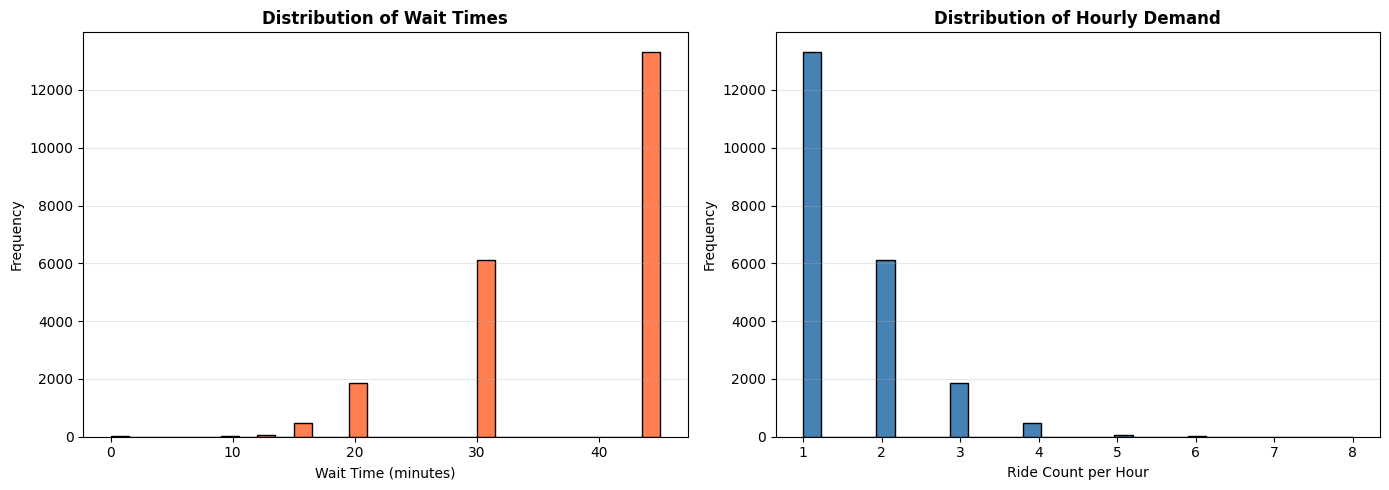


💾 Saved target variable distributions to 'target_distributions.png'


In [8]:
# STEP 6: CALCULATE WAIT TIME

print("\n⏱️  STEP 6: Calculating Wait Times")
print("="*60)

def calculate_wait_times(df_rides):
    wait_data = []
    
    zones = df_rides['pickup_zone'].unique()
    print(f"Calculating for {len(zones)} zones...")
    
    for i, zone in enumerate(zones):
        if (i + 1) % 10 == 0:
            print(f"  Processing zone {i+1}/{len(zones)}...")
        
        zone_data = df_rides[df_rides['pickup_zone'] == zone].copy()
        zone_data = zone_data.sort_values('booking_timestamp')
        
        zone_data['time_since_last_ride'] = zone_data['booking_timestamp'].diff()
        zone_data['wait_seconds'] = zone_data['time_since_last_ride'].dt.total_seconds()
        zone_data['wait_minutes'] = zone_data['wait_seconds'] / 60
        
        zone_data = zone_data[zone_data['wait_minutes'].notna()]
        
        zone_data['wait_minutes'] = zone_data['wait_minutes'].clip(upper=60)
        
        hourly_wait = zone_data.groupby(
            zone_data['booking_timestamp'].dt.floor('H')
        ).agg({
            'wait_minutes': 'mean'
        }).reset_index()
        
        hourly_wait.columns = ['hour_timestamp', 'wait_minutes']
        hourly_wait['pickup_zone'] = zone
        
        wait_data.append(hourly_wait)
    
    return pd.concat(wait_data, ignore_index=True)

wait_df = calculate_wait_times(df)

print(f"✅ Calculated wait times for all zones")

final_df = hourly_demand.merge(
    wait_df[['hour_timestamp', 'pickup_zone', 'wait_minutes']],
    on=['hour_timestamp', 'pickup_zone'],
    how='left'
)

final_df['wait_minutes'] = final_df['wait_minutes'].fillna(60)
final_df.loc[final_df['ride_count'] == 1, 'wait_minutes'] = 45

print(f"\n✅ Created final_df with {len(final_df)} rows")

print("\n📈 Target Variable (wait_minutes) Statistics:")
print(final_df['wait_minutes'].describe())

print("\n📊 Demand (ride_count) Statistics:")
print(final_df['ride_count'].describe())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(final_df['wait_minutes'], bins=30, color='coral', edgecolor='black')
ax1.set_xlabel('Wait Time (minutes)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Wait Times', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2.hist(final_df['ride_count'], bins=30, color='steelblue', edgecolor='black')
ax2.set_xlabel('Ride Count per Hour')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Hourly Demand', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved target variable distributions to 'target_distributions.png'")



In [14]:
# STEP 7: CREATE LAG FEATURES

print("\n🔄 STEP 7: Creating Lag Features")
print("="*60)

final_df = final_df.sort_values(['pickup_zone', 'hour_timestamp']).reset_index(drop=True)

print("Creating lag features for each zone...")

for zone in final_df['pickup_zone'].unique():
    zone_mask = final_df['pickup_zone'] == zone
    
    final_df.loc[zone_mask, 'demand_lag_1h'] = final_df.loc[zone_mask, 'ride_count'].shift(1)
    final_df.loc[zone_mask, 'demand_lag_2h'] = final_df.loc[zone_mask, 'ride_count'].shift(2)
    final_df.loc[zone_mask, 'demand_lag_24h'] = final_df.loc[zone_mask, 'ride_count'].shift(24)
    
    final_df.loc[zone_mask, 'demand_rolling_3h'] = final_df.loc[zone_mask, 'ride_count'].rolling(
        window=3, min_periods=1
    ).mean()
    
    final_df.loc[zone_mask, 'demand_rolling_24h'] = final_df.loc[zone_mask, 'ride_count'].rolling(
        window=24, min_periods=1
    ).mean()

print("✅ Created all lag features")

print("\n🧹 Removing rows with missing lag values...")
initial_rows = len(final_df)
final_df = final_df.dropna(subset=['demand_lag_1h', 'demand_lag_24h'])
print(f"   Removed {initial_rows - len(final_df)} rows")

print(f"\n✅ final_df now has {len(final_df)} rows and {len(final_df.columns)} columns")


# STEP 8: FINAL CLEANUP - SELECT ONLY ML FEATURES

print("\n🎯 STEP 8: Creating Clean ML-Ready Dataset")
print("="*60)

feature_columns = [
    'pickup_zone',
    'hour_timestamp',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos',
    'is_weekend',
    'demand_lag_1h',
    'demand_lag_2h',
    'demand_lag_24h',
    'demand_rolling_3h',
    'demand_rolling_24h',
    'hour',
    'day_of_week',
    'ride_count',
    'wait_minutes'
]

if 'avg_distance' in final_df.columns:
    feature_columns.append('avg_distance')

final_df_clean = final_df[feature_columns].copy()

print(f"✅ Created clean ML dataset")
print(f"   Rows: {len(final_df_clean)}")
print(f"   Columns: {len(final_df_clean.columns)}")

print(f"\n📋 Final ML Features:")
for i, col in enumerate(final_df_clean.columns, 1):
    marker = "🎯" if col == 'wait_minutes' else "📊" if col == 'ride_count' else "🔢"
    print(f"   {marker} {i}. {col}")

null_counts = final_df_clean.isnull().sum()
if null_counts.sum() > 0:
    print(f"\n⚠️  Warning: Found null values:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values - dataset is clean!")

print(f"\n📊 Data Types:")
print(final_df_clean.dtypes)

final_df_clean.to_csv('ml_ready_dataset_clean.csv', index=False)
print("\n💾 Saved clean ML-ready dataset to 'ml_ready_dataset_clean.csv'")




🔄 STEP 7: Creating Lag Features
Creating lag features for each zone...
✅ Created all lag features

🧹 Removing rows with missing lag values...
   Removed 1200 rows

✅ final_df now has 19460 rows and 18 columns

🎯 STEP 8: Creating Clean ML-Ready Dataset
✅ Created clean ML dataset
   Rows: 19460
   Columns: 17

📋 Final ML Features:
   🔢 1. pickup_zone
   🔢 2. hour_timestamp
   🔢 3. hour_sin
   🔢 4. hour_cos
   🔢 5. day_sin
   🔢 6. day_cos
   🔢 7. is_weekend
   🔢 8. demand_lag_1h
   🔢 9. demand_lag_2h
   🔢 10. demand_lag_24h
   🔢 11. demand_rolling_3h
   🔢 12. demand_rolling_24h
   🔢 13. hour
   🔢 14. day_of_week
   📊 15. ride_count
   🎯 16. wait_minutes
   🔢 17. avg_distance

✅ No null values - dataset is clean!

📊 Data Types:
pickup_zone                    int64
hour_timestamp        datetime64[ns]
hour_sin                     float64
hour_cos                     float64
day_sin                      float64
day_cos                      float64
is_weekend                     int64
demand

In [15]:
print("\n" + "="*70)
print("📊 FINAL DATASET SUMMARY")
print("="*70)

print(f"\n✅ Dataset Dimensions: {final_df_clean.shape[0]} rows × {final_df_clean.shape[1]} columns")
print(f"✅ Memory Usage: {final_df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"✅ Number of Zones: {final_df_clean['pickup_zone'].nunique()}")
print(f"✅ Date Range: {final_df_clean['hour_timestamp'].min()} to {final_df_clean['hour_timestamp'].max()}")

print(f"\n🎯 Target Variable Statistics:")
print(final_df_clean['wait_minutes'].describe())

print(f"\n📊 Feature Statistics:")
print(final_df_clean.describe())

print("\n" + "="*70)
print("✅ DATASET PREPARATION COMPLETE!")
print("="*70)
print("\n📌 Next Steps:")
print("   1. Load 'ml_ready_dataset_clean.csv'")
print("   2. Split into train/test (time-based)")
print("   3. Train XGBoost model")
print("   4. Evaluate performance")
print("\n🚀 Ready for Machine Learning!")


📊 FINAL DATASET SUMMARY

✅ Dataset Dimensions: 19460 rows × 17 columns
✅ Memory Usage: 2.52 MB
✅ Number of Zones: 50
✅ Date Range: 2024-01-03 20:00:00 to 2024-01-31 00:00:00

🎯 Target Variable Statistics:
count    19460.000000
mean        37.902933
std          9.427248
min          7.500000
25%         30.000000
50%         45.000000
75%         45.000000
max         45.000000
Name: wait_minutes, dtype: float64

📊 Feature Statistics:
        pickup_zone                 hour_timestamp      hour_sin  \
count  19460.000000                          19460  19460.000000   
mean      25.525797  2024-01-17 16:19:21.582733824     -0.007516   
min        1.000000            2024-01-03 20:00:00     -1.000000   
25%       13.000000            2024-01-11 02:00:00     -0.707107   
50%       25.000000            2024-01-17 16:00:00      0.000000   
75%       38.000000            2024-01-24 09:00:00      0.707107   
max       50.000000            2024-01-31 00:00:00      1.000000   
std       14.470

In [11]:
%pip install xgboost
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
print(final_df_clean.columns.tolist())
df = final_df_clean

['pickup_zone', 'hour_timestamp', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_weekend', 'demand_lag_1h', 'demand_lag_2h', 'demand_lag_24h', 'demand_rolling_3h', 'demand_rolling_24h', 'hour', 'day_of_week', 'ride_count', 'wait_minutes', 'avg_distance']


In [21]:
df.head()

,pickup_zone,hour_timestamp,hour_sin,hour_cos,day_sin,day_cos,is_weekend,demand_lag_1h,demand_lag_2h,demand_lag_24h,demand_rolling_3h,demand_rolling_24h,hour,day_of_week,ride_count,wait_minutes,avg_distance
24,1,2024-01-03 20:00:00,-0.866025,0.500000,0.974928,-0.222521,0,2.0,1.0,1.0,1.333333,1.375000,20,2,1,45.0,6.44
25,1,2024-01-03 21:00:00,-0.707107,0.707107,0.974928,-0.222521,0,1.0,2.0,1.0,1.333333,1.375000,21,2,1,45.0,8.51
26,1,2024-01-03 22:00:00,-0.500000,0.866025,0.974928,-0.222521,0,1.0,1.0,1.0,1.333333,1.416667,22,2,2,30.0,38.13
27,1,2024-01-03 23:00:00,-0.258819,0.965926,0.974928,-0.222521,0,2.0,1.0,1.0,1.333333,1.416667,23,2,1,45.0,43.98
28,1,2024-01-04 00:00:00,0.000000,1.000000,0.433884,-0.900969,0,1.0,2.0,1.0,1.666667,1.458333,0,3,2,30.0,21.54


In [44]:
# STEP 2: PREPARE FEATURES AND TARGET

feature_cols = [
    'pickup_zone',
    'hour_sin',
    'hour_cos', 
    'day_sin',
    'day_cos',
    'is_weekend',
    'demand_lag_1h',
    'demand_lag_2h',
    'demand_lag_24h',
    'demand_rolling_3h',
    'demand_rolling_24h',
    'avg_distance'
]

#if 'avg_distance' in df.columns:
 #   feature_cols.append('avg_distance')

X = df[feature_cols].copy()
y_wait = df['wait_minutes'].values
y_demand = df['ride_count'].values

print("\n" + "="*70)
print("STEP 2: FEATURES AND TARGET PREPARED")
print("="*70)
print(f"Features shape: {X.shape}")
print(f"Target (wait_minutes) shape: {y_wait.shape}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")



STEP 2: FEATURES AND TARGET PREPARED
Features shape: (19460, 12)
Target (wait_minutes) shape: (19460,)

Feature columns:
  1. pickup_zone
  2. hour_sin
  3. hour_cos
  4. day_sin
  5. day_cos
  6. is_weekend
  7. demand_lag_1h
  8. demand_lag_2h
  9. demand_lag_24h
  10. demand_rolling_3h
  11. demand_rolling_24h
  12. avg_distance


In [45]:
#Time based train test split

df_sorted = df.sort_values('hour_timestamp').reset_index(drop=True)
X_sorted = df_sorted[feature_cols].copy()
y_wait_sorted = df_sorted['wait_minutes'].values
y_demand_sorted = df_sorted['ride_count'].values
timestamps = df_sorted['hour_timestamp'].values

split_idx = int(len(df_sorted) * 0.8)

X_train = X_sorted.iloc[:split_idx]
X_test = X_sorted.iloc[split_idx:]
y_train = y_wait_sorted[:split_idx]
y_test = y_wait_sorted[split_idx:]  
y_train_demand = y_demand_sorted[:split_idx]
y_test_demand = y_demand_sorted[split_idx:]

train_dates = timestamps[:split_idx]
test_dates = timestamps[split_idx:]

print("\n" + "="*70)
print("STEP 3: TIME-BASED TRAIN-TEST SPLIT")
print("="*70)
print(f"Training set: {len(X_train)} rows ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Date range: {train_dates[0]} to {train_dates[-1]}")
print(f"Test set: {len(X_test)} rows ({len(X_test)/len(df)*100:.1f}%)")
print(f"  Date range: {test_dates[0]} to {test_dates[-1]}")




STEP 3: TIME-BASED TRAIN-TEST SPLIT
Training set: 15568 rows (80.0%)
  Date range: 2024-01-03T20:00:00.000000000 to 2024-01-25T17:00:00.000000000
Test set: 3892 rows (20.0%)
  Date range: 2024-01-25T17:00:00.000000000 to 2024-01-31T00:00:00.000000000


In [46]:
# STEP 4: TRAIN XGBOOST MODEL FOR WAIT TIME PREDICTION

print("\n" + "="*70)
print("STEP 4: TRAINING XGBOOST MODEL (Wait Time)")
print("="*70)

xgb_wait = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_wait.fit(X_train, y_train)
print("✅ XGBoost model trained successfully")

y_pred_wait = xgb_wait.predict(X_test)

mae_wait = mean_absolute_error(y_test, y_pred_wait)
rmse_wait = np.sqrt(mean_squared_error(y_test, y_pred_wait))
r2_wait = r2_score(y_test, y_pred_wait)
mape_wait = np.mean(np.abs((y_test - y_pred_wait) / (y_test + 1e-8))) * 100

print(f"\n📊 Wait Time Prediction Performance:")
print(f"  MAE:  {mae_wait:.2f} minutes")
print(f"  RMSE: {rmse_wait:.2f} minutes")
print(f"  R²:   {r2_wait:.3f}")
print(f"  MAPE: {mape_wait:.2f}%")


# STEP 5: TRAIN XGBOOST MODEL FOR DEMAND PREDICTION

print("\n" + "="*70)
print("STEP 5: TRAINING XGBOOST MODEL (Ride Demand)")
print("="*70)

# 1. Define the model (same hyperparameters as before)
xgb_demand = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 2. Train on the DEMAND target
# Note: We use y_train_demand here, not y_train
xgb_demand.fit(X_train, y_train_demand)
print("✅ XGBoost demand model trained successfully")

# 3. Evaluate
y_pred_demand = xgb_demand.predict(X_test)
mae_demand = mean_absolute_error(y_test_demand, y_pred_demand)
rmse_demand = np.sqrt(mean_squared_error(y_test_demand, y_pred_demand))
r2_demand = r2_score(y_test_demand, y_pred_demand)

print(f"\n📊 Demand Prediction Performance:")
print(f"  MAE:  {mae_demand:.2f} rides")
print(f"  RMSE: {rmse_demand:.2f} rides")
print(f"  R²:   {r2_demand:.3f}")


STEP 4: TRAINING XGBOOST MODEL (Wait Time)
✅ XGBoost model trained successfully

📊 Wait Time Prediction Performance:
  MAE:  0.23 minutes
  RMSE: 0.67 minutes
  R²:   0.995
  MAPE: 0.78%

STEP 5: TRAINING XGBOOST MODEL (Ride Demand)
✅ XGBoost demand model trained successfully

📊 Demand Prediction Performance:
  MAE:  0.02 rides
  RMSE: 0.05 rides
  R²:   0.996



STEP 6: FEATURE IMPORTANCE ANALYSIS

🔝 Top 10 Most Important Features:
  demand_rolling_3h        : 0.4322
  demand_lag_2h            : 0.2898
  demand_lag_1h            : 0.2213
  avg_distance             : 0.0306
  demand_rolling_24h       : 0.0066
  day_sin                  : 0.0040
  hour_cos                 : 0.0034
  demand_lag_24h           : 0.0030
  day_cos                  : 0.0027
  hour_sin                 : 0.0023


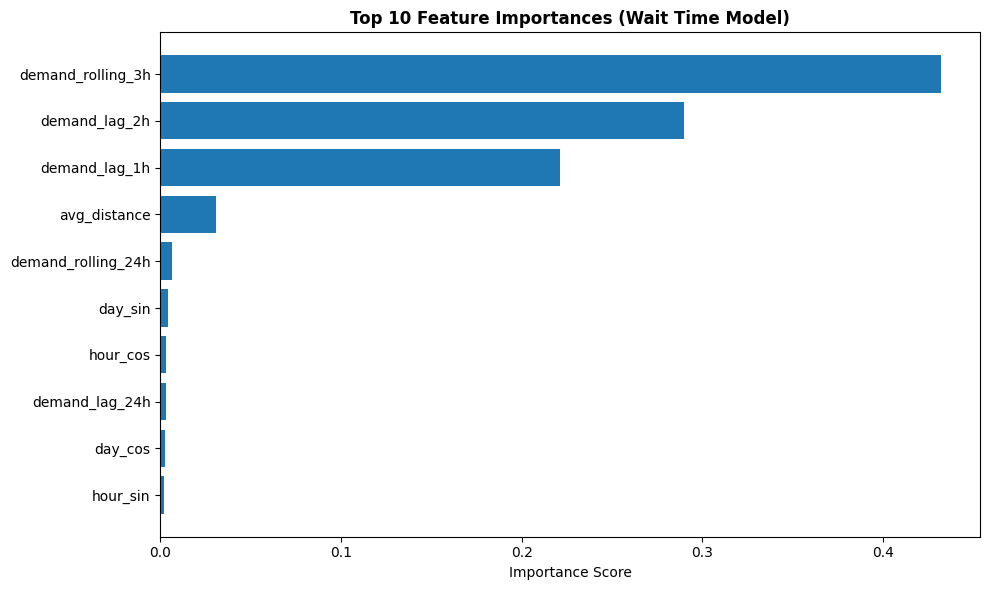


💾 Saved feature importance plot


In [47]:
# STEP 6: FEATURE IMPORTANCE ANALYSIS

print("\n" + "="*70)
print("STEP 6: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_wait.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔝 Top 10 Most Important Features:")
for idx, row in importance_df.head(10).iterrows():
    print(f"  {row['feature']:25s}: {row['importance']:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importances (Wait Time Model)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n💾 Saved feature importance plot")


STEP 7: VISUALIZATION OF PREDICTIONS


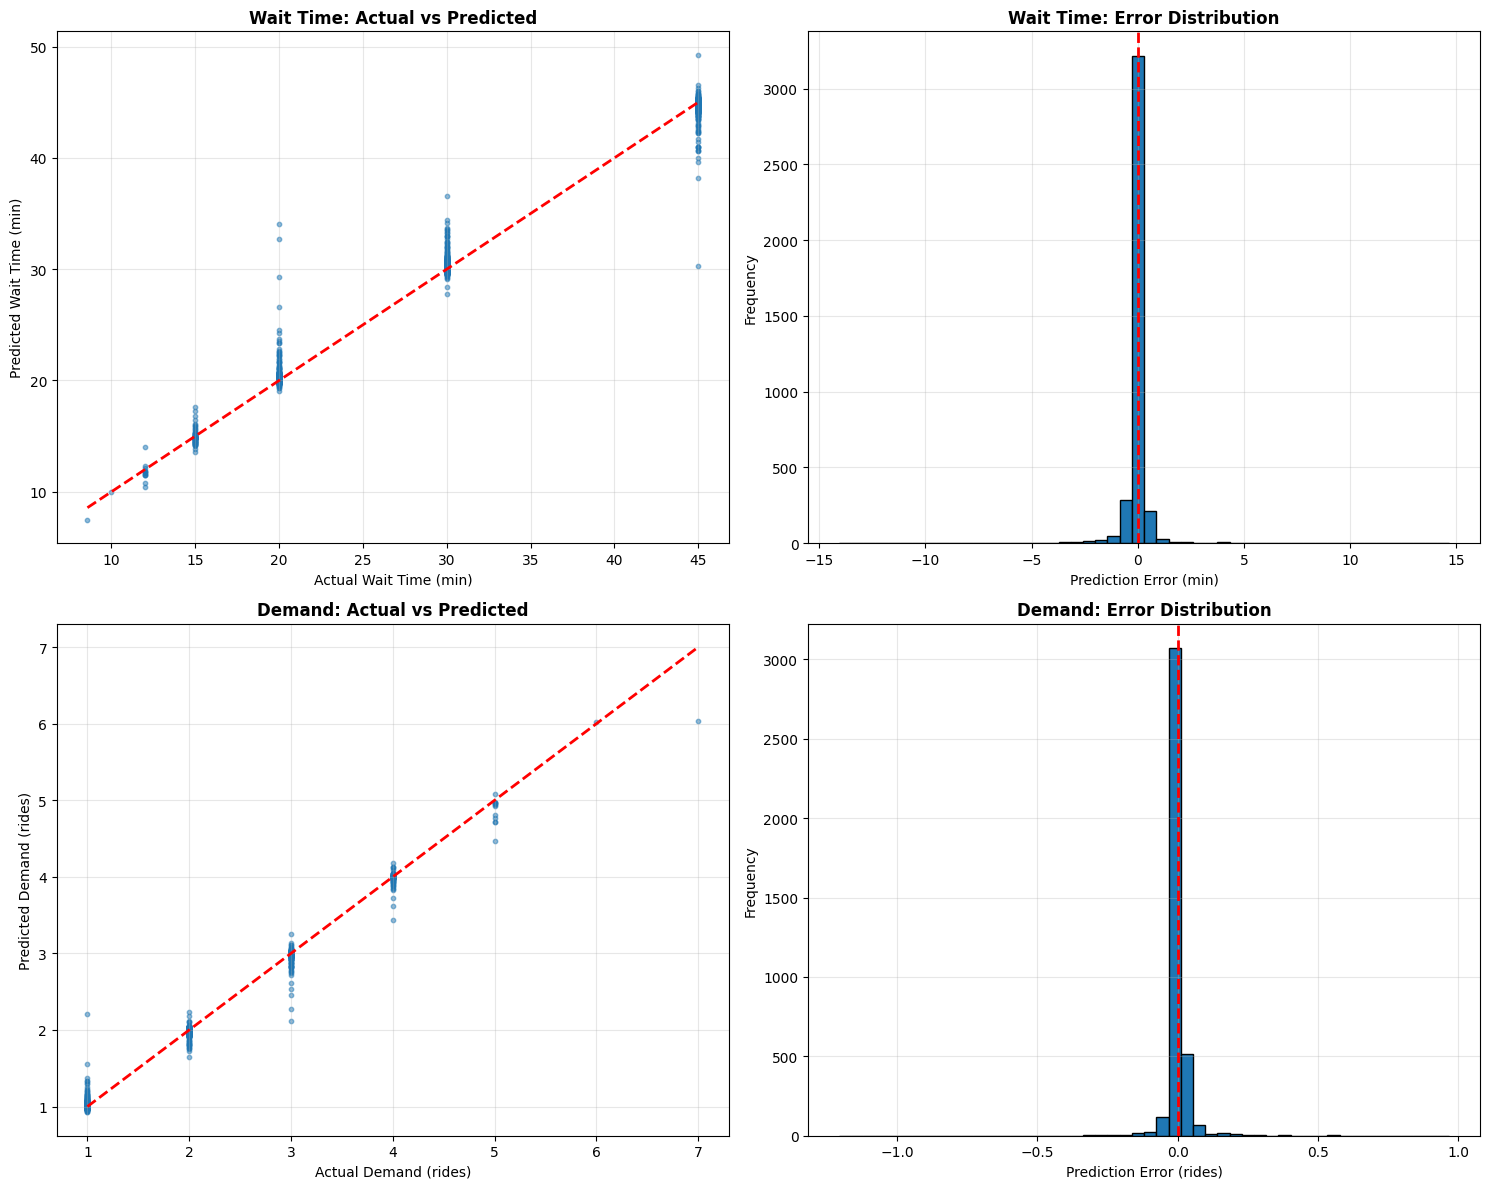

💾 Saved prediction analysis plots


In [48]:
# STEP 7: VISUALIZE PREDICTIONS VS ACTUAL

print("\n" + "="*70)
print("STEP 7: VISUALIZATION OF PREDICTIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].scatter(y_test, y_pred_wait, alpha=0.5, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Wait Time (min)')
axes[0, 0].set_ylabel('Predicted Wait Time (min)')
axes[0, 0].set_title('Wait Time: Actual vs Predicted', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

residuals_wait = y_test - y_pred_wait
axes[0, 1].hist(residuals_wait, bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Prediction Error (min)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Wait Time: Error Distribution', fontweight='bold')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].scatter(y_test_demand, y_pred_demand, alpha=0.5, s=10)
axes[1, 0].plot([y_test_demand.min(), y_test_demand.max()], 
                [y_test_demand.min(), y_test_demand.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Demand (rides)')
axes[1, 0].set_ylabel('Predicted Demand (rides)')
axes[1, 0].set_title('Demand: Actual vs Predicted', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

residuals_demand = y_test_demand - y_pred_demand
axes[1, 1].hist(residuals_demand, bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Prediction Error (rides)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Demand: Error Distribution', fontweight='bold')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved prediction analysis plots")


In [49]:
# STEP 8: TIME-SERIES CROSS-VALIDATION

print("\n" + "="*70)
print("STEP 8: TIME-SERIES CROSS-VALIDATION")
print("="*70)

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted), 1):
    X_fold_train = X_sorted.iloc[train_idx]
    X_fold_val = X_sorted.iloc[val_idx]
    y_fold_train = y_wait_sorted[train_idx]
    y_fold_val = y_wait_sorted[val_idx]
    
    model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    model.fit(X_fold_train, y_fold_train)
    
    y_fold_pred = model.predict(X_fold_val)
    
    mae = mean_absolute_error(y_fold_val, y_fold_pred)
    rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
    r2 = r2_score(y_fold_val, y_fold_pred)
    
    cv_scores.append({'fold': fold, 'mae': mae, 'rmse': rmse, 'r2': r2})
    print(f"Fold {fold}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")

cv_df = pd.DataFrame(cv_scores)
print(f"\n📊 Cross-Validation Summary:")
print(f"  Average MAE:  {cv_df['mae'].mean():.2f} ± {cv_df['mae'].std():.2f}")
print(f"  Average RMSE: {cv_df['rmse'].mean():.2f} ± {cv_df['rmse'].std():.2f}")
print(f"  Average R²:   {cv_df['r2'].mean():.3f} ± {cv_df['r2'].std():.3f}")



STEP 8: TIME-SERIES CROSS-VALIDATION
Fold 1: MAE=0.13, RMSE=0.85, R²=0.992
Fold 2: MAE=0.07, RMSE=0.71, R²=0.994
Fold 3: MAE=0.09, RMSE=0.90, R²=0.991
Fold 4: MAE=0.04, RMSE=0.37, R²=0.998
Fold 5: MAE=0.04, RMSE=0.37, R²=0.998

📊 Cross-Validation Summary:
  Average MAE:  0.07 ± 0.04
  Average RMSE: 0.64 ± 0.26
  Average R²:   0.995 ± 0.004


In [50]:
# STEP 9: ERROR ANALYSIS BY ZONE AND TIME

print("\n" + "="*70)
print("STEP 9: ERROR ANALYSIS BY ZONE AND TIME")
print("="*70)

test_results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_wait,
    'error': np.abs(y_test - y_pred_wait),
    'zone': df_sorted.iloc[split_idx:]['pickup_zone'].values,
    'hour': df_sorted.iloc[split_idx:]['hour'].values
})

zone_errors = test_results.groupby('zone')['error'].mean().sort_values(ascending=False)
print("\n🔍 Top 5 Zones with Highest Prediction Error:")
for zone, error in zone_errors.head(5).items():
    print(f"  Zone {zone}: {error:.2f} min average error")

print("\n🔍 Top 5 Zones with Lowest Prediction Error:")
for zone, error in zone_errors.tail(5).items():
    print(f"  Zone {zone}: {error:.2f} min average error")

hour_errors = test_results.groupby('hour')['error'].mean().sort_values(ascending=False)
print("\n🔍 Top 5 Hours with Highest Prediction Error:")
for hour, error in hour_errors.head(5).items():
    print(f"  Hour {hour}: {error:.2f} min average error")



STEP 9: ERROR ANALYSIS BY ZONE AND TIME

🔍 Top 5 Zones with Highest Prediction Error:
  Zone 14: 0.53 min average error
  Zone 47: 0.53 min average error
  Zone 6: 0.51 min average error
  Zone 44: 0.41 min average error
  Zone 45: 0.40 min average error

🔍 Top 5 Zones with Lowest Prediction Error:
  Zone 24: 0.14 min average error
  Zone 42: 0.13 min average error
  Zone 27: 0.13 min average error
  Zone 43: 0.11 min average error
  Zone 34: 0.11 min average error

🔍 Top 5 Hours with Highest Prediction Error:
  Hour 12: 0.36 min average error
  Hour 15: 0.36 min average error
  Hour 8: 0.32 min average error
  Hour 14: 0.31 min average error
  Hour 9: 0.31 min average error


In [51]:
# STEP 10: SAVE MODELS

print("\n" + "="*70)
print("STEP 10: SAVING MODELS")
print("="*70)

joblib.dump(xgb_wait, 'xgb_wait_time_model.pkl')
print("✅ Saved wait time model to 'xgb_wait_time_model.pkl'")

joblib.dump(xgb_demand, 'xgb_demand_model.pkl')
print("✅ Saved demand model to 'xgb_demand_model.pkl'")

model_metadata = {
    'feature_columns': feature_cols,
    'wait_time_metrics': {
        'mae': mae_wait,
        'rmse': rmse_wait,
        'r2': r2_wait,
        'mape': mape_wait
    },
    'demand_metrics': {
        'mae': mae_demand,
        'rmse': rmse_demand,
        'r2': r2_demand
    },
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'num_zones': df['pickup_zone'].nunique()
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("✅ Saved model metadata to 'model_metadata.json'")



STEP 10: SAVING MODELS
✅ Saved wait time model to 'xgb_wait_time_model.pkl'
✅ Saved demand model to 'xgb_demand_model.pkl'
✅ Saved model metadata to 'model_metadata.json'


In [56]:
# STEP 11: CREATE PREDICTION FUNCTION

print("\n" + "="*70)
print("STEP 11: CREATING PREDICTION FUNCTION")
print("="*70)

def predict_zone_rankings(current_datetime, model_wait, model_demand, zones, feature_cols):
    predictions = []

    avg_dist_val = df['avg_distance'].mean()
    hour = current_datetime.hour
    day_of_week = current_datetime.dayofweek
    is_weekend = 1 if day_of_week >= 5 else 0
    
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    day_sin = np.sin(2 * np.pi * day_of_week / 7)
    day_cos = np.cos(2 * np.pi * day_of_week / 7)
    
    for zone in zones:
        features = {
            'pickup_zone': zone,
            'hour_sin': hour_sin,
            'hour_cos': hour_cos,
            'day_sin': day_sin,
            'day_cos': day_cos,
            'is_weekend': is_weekend,
            'demand_lag_1h': 0,
            'demand_lag_2h': 0,
            'demand_lag_24h': 0,
            'demand_rolling_3h': 0,
            'demand_rolling_24h': 0,
            'avg_distance': avg_dist_val
        }
        
        predictions.append(features)
    
    pred_df = pd.DataFrame(predictions)[feature_cols]
    
    wait_times = model_wait.predict(pred_df)
    demands = model_demand.predict(pred_df)
    
    results = pd.DataFrame({
        'zone': zones,
        'predicted_wait_min': wait_times,
        'predicted_demand': demands,
        'score': demands / (wait_times + 1)
    }).sort_values('score', ascending=False)
    
    return results

all_zones = df['pickup_zone'].unique()
sample_datetime = pd.Timestamp('2024-03-15 17:00:00')

rankings = predict_zone_rankings(sample_datetime, xgb_wait, xgb_demand, all_zones, feature_cols)

print(f"\n🎯 Sample Prediction for {sample_datetime}:")
print("\nTop 5 Recommended Zones:")
print(rankings.head(5).to_string(index=False))
print("\nWorst 5 Zones to Avoid:")
print(rankings.tail(5).to_string(index=False))



STEP 11: CREATING PREDICTION FUNCTION

🎯 Sample Prediction for 2024-03-15 17:00:00:

Top 5 Recommended Zones:
 zone  predicted_wait_min  predicted_demand    score
   44           44.955147          0.997556 0.021707
   43           44.955147          0.997556 0.021707
   46           44.955147          0.997556 0.021707
   45           44.955147          0.997556 0.021707
   41           44.955147          0.997556 0.021707

Worst 5 Zones to Avoid:
 zone  predicted_wait_min  predicted_demand    score
    7           45.043549          0.997667 0.021668
    3           45.045559          0.997667 0.021667
    5           45.045559          0.997667 0.021667
    4           45.045559          0.997667 0.021667
   16           45.041733          0.997556 0.021666


In [57]:
# STEP 12: BUSINESS IMPACT CALCULATION

print("\n" + "="*70)
print("STEP 12: BUSINESS IMPACT CALCULATION")
print("="*70)

baseline_km_per_ride = 5
optimized_km_per_ride = 2
fuel_efficiency_kmpl = 15
fuel_cost_per_liter = 100

total_test_rides = len(y_test)
km_saved_per_ride = baseline_km_per_ride - optimized_km_per_ride
total_km_saved = total_test_rides * km_saved_per_ride
total_fuel_saved = total_km_saved / fuel_efficiency_kmpl
total_cost_saved = total_fuel_saved * fuel_cost_per_liter

time_saved_per_ride = np.mean(y_test - y_pred_wait.clip(min=0))
total_time_saved_hours = (time_saved_per_ride * total_test_rides) / 60

print(f"\n💰 Estimated Business Impact (Test Period):")
print(f"  Total rides: {total_test_rides:,}")
print(f"  Distance saved: {total_km_saved:,.0f} km")
print(f"  Fuel saved: {total_fuel_saved:,.0f} liters")
print(f"  Cost saved: ₹{total_cost_saved:,.0f}")
print(f"  Time saved: {total_time_saved_hours:,.0f} hours")

per_driver_rides = 10
per_driver_km = per_driver_rides * km_saved_per_ride
per_driver_fuel = per_driver_km / fuel_efficiency_kmpl
per_driver_savings = per_driver_fuel * fuel_cost_per_liter * 30

print(f"\n👤 Per Driver Monthly Impact (assuming {per_driver_rides} rides/day):")
print(f"  Fuel saved: {per_driver_fuel * 30:,.0f} liters/month")
print(f"  Cost saved: ₹{per_driver_savings:,.0f}/month")



STEP 12: BUSINESS IMPACT CALCULATION

💰 Estimated Business Impact (Test Period):
  Total rides: 3,892
  Distance saved: 11,676 km
  Fuel saved: 778 liters
  Cost saved: ₹77,840
  Time saved: -2 hours

👤 Per Driver Monthly Impact (assuming 10 rides/day):
  Fuel saved: 60 liters/month
  Cost saved: ₹6,000/month
